<a href="https://colab.research.google.com/github/elvingup/projeto_deteccao_python_data_analytics_20260821/blob/main/projeto_deteccao_python_data_analytics_20260821.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DETECÇÃO DE FRAUDES EM TRANSAÇÕES BANCÁRIAS DO DATASET CREDITCARD

In [ ]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# # Determinar a quantidade de itens de cada valor correspondentes à feature "Class"
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


In [ ]:
# FEATURING ENGINEERING: transformação algorítmica da feature "Amount"

import numpy as np

# criar a feature "Amount_log" referenciado-se na feature "Amount" visando
# calibrar a ESCALA DE DADOS visto que valores pequenos poderiam dificultar a
# IDENTIFICAÇÃO DE PADRÕES que podem estar presentes no dataset
df["Amount_log"] = np.log1p(df[["Amount"]])


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# criar a feature "Amount_scaled" para ajustar a ESCALA DOS DADOS de modo a evitar o viés de alguma coluna com números muito maiores que o restante das colunas. Faz isso ao calcular a MÉDIA e o DESVIO PADRÃO da feature "Amount"
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [ ]:
# FEATURING ENGINEERING: treinar o modelo

from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)


In [ ]:
# Avaliação dos Modelos empregando Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Impressão do Relatório

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



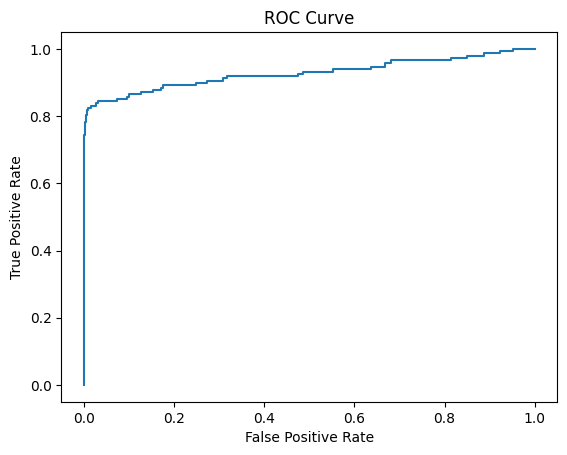

AUC:  0.9272042339543365


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Se o modelo for preciso, o valor de AUC deve ser próximo de 1.00
print("AUC: ", roc_auc_score(y_test, y_probs))

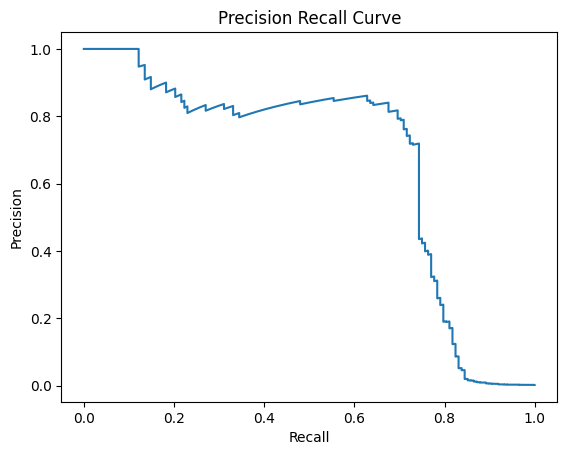

In [ ]:
# Precision Recall Curve para comparar a "Quantidade de Fraudes Detectadas" contra a "Quantidade de Fraudes que são fraudes mesmo"

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [ ]:
# BALANCEAMENTO DE DADOS: Undersampling para reduzir a classe majoritária

fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state = 42)

df_under = pd.concat([fraudes, normais])

In [ ]:
# BALANCEAMENTO DE DADOS: Oversampling para aumentar a classe minoritária

from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

In [ ]:
#  BALANCEAMENTO DE DADOS: Floresta de Árvores de Decisão

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
# PIPELINE

from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)


In [ ]:
# AJUSTE DE LIMIAR

threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
# XGBoost - uso de boosting (sequencia de treinamentos de modelos simples que convergem para corrigir os treinamentos anteriores): algoritmo que é muito apreciado no Mercado

from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
# Exibição do XGBoost

print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



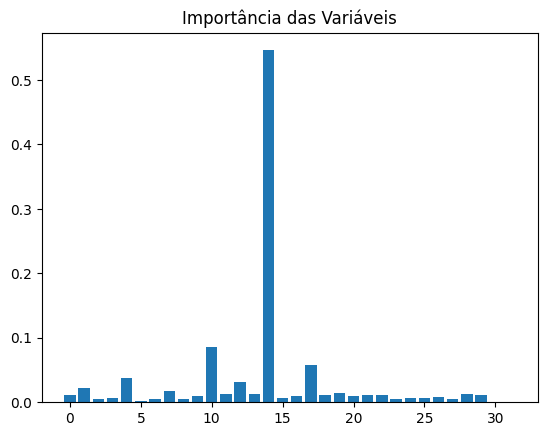

In [ ]:
# Exibição da importância das variáveis

import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.show()


In [ ]:
# AJUSTE DE HIPERPARÂMETROS: Melhorar o Modelo ao testar várias combinações

# GridSearchCV testa várias combinações de parâmetros visando encontrar a melhor dentre elas.
from sklearn.model_selection import GridSearchCV

# Definição das combinações a serem testadas
param_grid = {
    "max_depth": [3,5],
    "n_estimators": [50,100]
}

# Treinamento de vários modelos (um modelo respectivamente a um parâmetro) e determinação do recall como critério de avaliação de bom desempenho
grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring = "recall",
    cv = 3
)

grid.fit(X_train, y_train)

# Exibição do resultado da avaliação
print("Melhor modelo: ", grid.best_params_)

Melhor modelo:  {'max_depth': 5, 'n_estimators': 100}


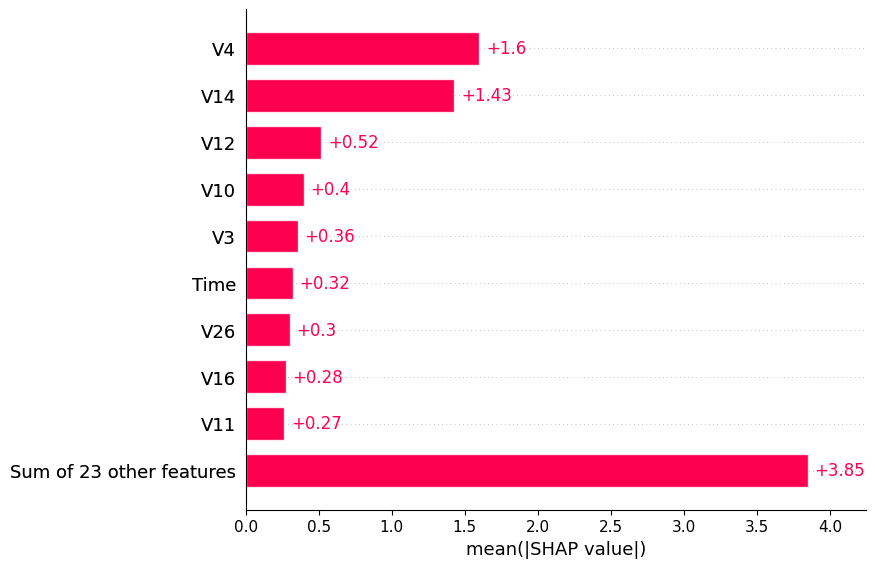

In [ ]:
# EXPLICABILIDADE (SHAP): mostra como cada feature contriubui para a decisão do modelo

import shap

# Invocação da funcionalidade SHAP
explainer = shap.Explainer(xgb)

# Seleção dos valores
shap_values = explainer(X_test[:100])

# Exibição dos valores
shap.plots.bar(shap_values)

### Métricas puras de Machine Learning como *Recall* e *Precision* mostram apenas o desempenho estático do algoritmo. Ao traduzir essas métricas para moeda corrente, vamos perceber que o modelo reduz o prejuízo operacional com fraudes: mesmo considerando o custo operacional e atrito de alarmes falsos.

In [ ]:
# Avaliação de Efeito Financeiro e Valor de Negócio

import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd # Garante que pandas esteja importado para a função

def analisar_impacto_financeiro(y_true, y_pred, valores_transacoes, custo_fp=20.0):
    """
    Calcula o impacto financeiro do modelo de detecção de fraude.

    Parameters:
    - y_true: Rótulos reais (0 = Legítima, 1 = Fraude)
    - y_pred: Predições do modelo (0 ou 1)
    - valores_transacoes: Séries com os valores financeiros das transações (Amount)
    - custo_fp: Custo estimado de um alarme falso (Falso Positivo)
    """
    df_resultado = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'amount': valores_transacoes
    })

    # Matriz de Confusão
    tn, fp, fn, tp = confusion_matrix(df_resultado['y_true'], df_resultado['y_pred']).ravel()

    # Cálculo dos custos
    custo_total_fp = fp * custo_fp

    # Para o FN (Fraude não detectada), somamos o valor real das transações fraudulentas que passaram
    custo_total_fn = df_resultado[(df_resultado['y_true'] == 1) & (df_resultado['y_pred'] == 0)]['amount'].sum()

    # Custo total com o modelo operando
    custo_com_modelo = custo_total_fp + custo_total_fn

    # Custo baseline (Cenário sem modelo: aprovar todas as transações -> todas as fraudes viram FN)
    custo_sem_modelo = df_resultado[df_resultado['y_true'] == 1]['amount'].sum()

    # Economia gerada
    economia = custo_sem_modelo - custo_com_modelo
    roi_percentual = (economia / custo_sem_modelo) * 100 if custo_sem_modelo > 0 else 0

    # Exibição dos resultados estruturados
    print("=" * 40)
    print("Análise de Impacto Financeiro")
    print("=" * 40)
    print(f"Custo sem modelo (todas as fraudes não detectadas): R$ {custo_sem_modelo:,.2f}")
    print(f"Custo com modelo (FP + FN): R$ {custo_com_modelo:,.2f}")
    print(f"Economia gerada pelo modelo: R$ {economia:,.2f}")
    print(f"ROI (Retorno sobre Investimento) do modelo: {roi_percentual:,.2f}%")
    print("=" * 40)
    print(f"Detalhes da Matriz de Confusão:")
    print(f"Verdadeiros Negativos (TN): {tn}")
    print(f"Falsos Positivos (FP): {fp}")
    print(f"Falsos Negativos (FN): {fn}")
    print(f"Verdadeiros Positivos (TP): {tp}")
    print("=" * 40)

In [ ]:
# Chamada da função de análise de impacto financeiro com as predições do modelo XGBoost
analisar_impacto_financeiro(y_test, y_pred_xgb, X_test['Amount'])

Análise de Impacto Financeiro
Custo sem modelo (todas as fraudes não detectadas): R$ 19,311.89
Custo com modelo (FP + FN): R$ 7,781.01
Economia gerada pelo modelo: R$ 11,530.88
ROI (Retorno sobre Investimento) do modelo: 59.71%
Detalhes da Matriz de Confusão:
Verdadeiros Negativos (TN): 85288
Falsos Positivos (FP): 7
Falsos Negativos (FN): 33
Verdadeiros Positivos (TP): 115


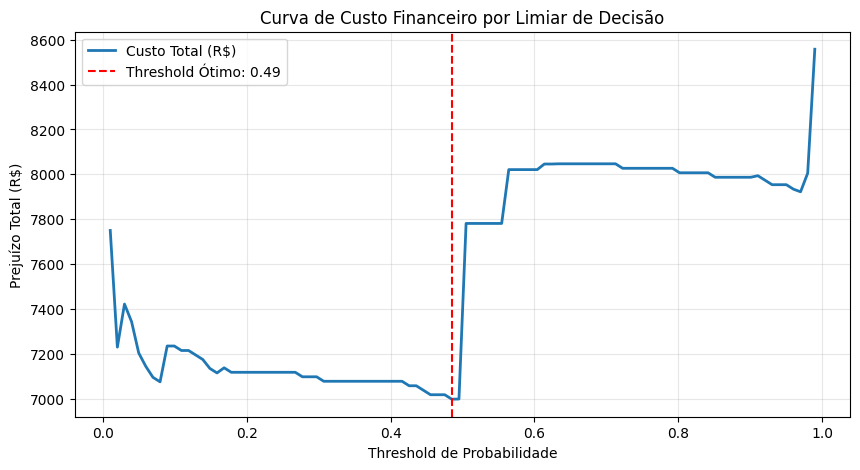

Limiar ideal de corte financeiro: 0.49 com prejuízo mínimo de R$ 6,997.49


In [ ]:
# Otimização do Limiar de Decisão (Threshold Tuning)

def otimizar_threshold_financeiro(model, X_test, y_test, valores_transacoes, custo_fp=20.0):
    probas = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 100)
    custos = []

    for t in thresholds:
        y_pred = (probas >= t).astype(int)

        # Falsos positivos
        fp = np.sum((y_pred == 1) & (y_test == 0))
        custo_fp_total = fp * custo_fp

        # Falsos negativos (soma dos valores)
        fn_mask = (y_pred == 0) & (y_test == 1)
        custo_fn_total = valores_transacoes[fn_mask].sum()

        custos.append(custo_fp_total + custo_fn_total)

    idx_melhor = np.argmin(custos)
    melhor_threshold = thresholds[idx_melhor]
    menor_custo = custos[idx_melhor]

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, custos, color='#1f77b4', linewidth=2, label='Custo Total (R$)')
    plt.axvline(melhor_threshold, color='red', linestyle='--', label=f'Threshold Ótimo: {melhor_threshold:.2f}')
    plt.title('Curva de Custo Financeiro por Limiar de Decisão')
    plt.xlabel('Threshold de Probabilidade')
    plt.ylabel('Prejuízo Total (R$)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Limiar ideal de corte financeiro: {melhor_threshold:.2f} com prejuízo mínimo de R$ {menor_custo:,.2f}")

# Executar otimização
otimizar_threshold_financeiro(xgb, X_test, y_test, X_test['Amount'])

Os resultados estruturados da análise de impacto financeiro para as predições padrão do modelo XGBoost foram exibidos acima. Para usar as predições com o `limiar ideal de corte financeiro` que foi otimizado, seria necessário capturar esse limiar da saída da função `otimizar_threshold_financeiro` e, então, recriar as predições (`y_pred`) com base nesse novo limiar para passar para a função `analisar_impacto_financeiro`.